# Artificial Neural Networks — SONAR: Mines vs. Rocks

### Objective
Build an Artificial Neural Network (ANN) to classify sonar returns as **Mine (M)** or **Rock (R)**.

The dataset contains 208 observations, 60 numerical sonar features, and one categorical target variable (`Y`).

## 1. Data Exploration and Preprocessing

We first load the dataset, inspect its structure, check missing values and duplicates, examine the class distribution, encode the target, split the data, and standardize the input features.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)
tf.random.set_seed(42)

In [2]:
df = pd.read_csv("sonardataset.csv")
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (208, 61)


,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60,Y
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 61 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x_1     208 non-null    float64
 1   x_2     208 non-null    float64
 2   x_3     208 non-null    float64
 3   x_4     208 non-null    float64
 4   x_5     208 non-null    float64
 5   x_6     208 non-null    float64
 6   x_7     208 non-null    float64
 7   x_8     208 non-null    float64
 8   x_9     208 non-null    float64
 9   x_10    208 non-null    float64
 10  x_11    208 non-null    float64
 11  x_12    208 non-null    float64
 12  x_13    208 non-null    float64
 13  x_14    208 non-null    float64
 14  x_15    208 non-null    float64
 15  x_16    208 non-null    float64
 16  x_17    208 non-null    float64
 17  x_18    208 non-null    float64
 18  x_19    208 non-null    float64
 19  x_20    208 non-null    float64
 20  x_21    208 non-null    float64
 21  x_22    208 non-null    float64
 22  x_23    208 n

In [4]:
df.describe()

,x_1,x_2,x_3,x_4,x_5,x_6,x_7,x_8,x_9,x_10,...,x_51,x_52,x_53,x_54,x_55,x_56,x_57,x_58,x_59,x_60
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [5]:
print("Total missing values:", df.isnull().sum().sum())
print("Number of duplicate rows:", df.duplicated().sum())

Total missing values: 0
Number of duplicate rows: 0


### Interpretation

The dataset contains **208 observations and 61 columns**: 60 numerical sonar features and one target column. The dataset has **no missing values and no duplicate rows**, so no imputation or duplicate removal is required.

Class distribution:
Y
M    111
R     97
Name: count, dtype: int64


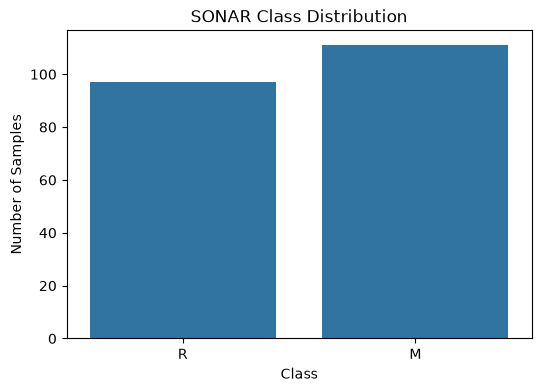

In [6]:
print("Class distribution:")
print(df["Y"].value_counts())
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Y")
plt.title("SONAR Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.show()

The target contains two classes: **M = Mine** and **R = Rock**. The class distribution is reasonably balanced, so no special class-balancing technique is required.

In [7]:
X = df.drop("Y", axis=1)
y = df["Y"].map({"R": 0, "M": 1})
print("Input features:", X.shape[1])
print("Target classes:", y.unique())

Input features: 60
Target classes: [0 1]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training samples:", X_train.shape[0])
print("Testing samples :", X_test.shape[0])

Training samples: 166
Testing samples : 42


In [9]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Training data shape:", X_train_scaled.shape)
print("Testing data shape :", X_test_scaled.shape)

Training data shape: (166, 60)
Testing data shape : (42, 60)


### Why standardization?

The 60 sonar variables have different distributions and scales. Standardization transforms the training features so that they are centered around zero with comparable variance. The scaler is fitted **only on the training data** and then applied to the test data to avoid data leakage.

## 2. Basic ANN Model

The basic model contains:
- Input: 60 features
- Hidden layer: 32 neurons with ReLU
- Output layer: 1 neuron with sigmoid
- Loss: binary cross-entropy
- Optimizer: Adam
- Learning rate: 0.001

In [10]:
def build_ann(hidden_layers=1,
              neurons=32,
              activation="relu",
              learning_rate=0.001,
              dropout_rate=0.0):

    model = Sequential()
    model.add(Input(shape=(60,)))

    for _ in range(hidden_layers):
        model.add(Dense(neurons, activation=activation))
        if dropout_rate > 0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [11]:
basic_model = build_ann(
    hidden_layers=1,
    neurons=32,
    activation="relu",
    learning_rate=0.001
)

basic_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 32)                  │           1,952 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,985 (7.75 KB)

 Trainable params: 1,985 (7.75 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

basic_history = basic_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5606 - loss: 0.8065 - val_accuracy: 0.5000 - val_loss: 1.0290
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6212 - loss: 0.6767 - val_accuracy: 0.5294 - val_loss: 0.8701
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6667 - loss: 0.5911 - val_accuracy: 0.6176 - val_loss: 0.7521
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6970 - loss: 0.5331 - val_accuracy: 0.6471 - val_loss: 0.6742
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.4904 - val_accuracy: 0.6765 - val_loss: 0.6215
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7803 - loss: 0.4561 - val_accuracy: 0.6471 - val_loss: 0.5839
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7955 - loss: 0.4272 - val_accuracy: 0.7059 - val_loss: 0.5562
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8030 - loss: 0.4020 - val_accuracy: 0.7647 - val_loss: 0.5350

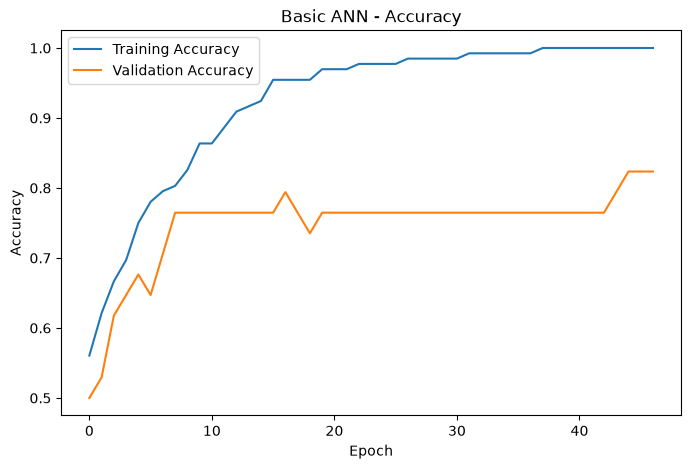

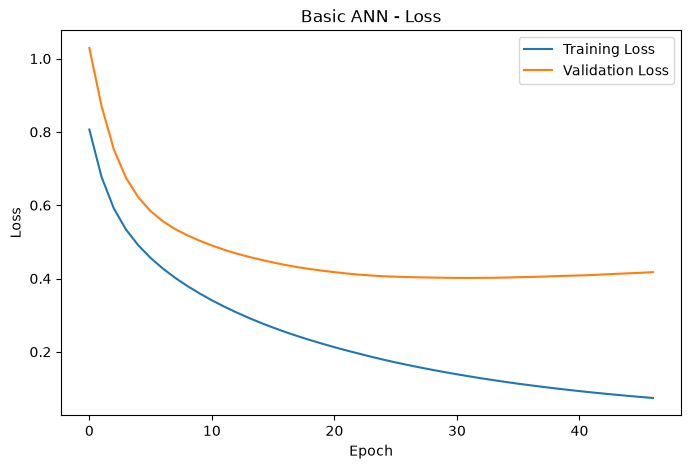

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(basic_history.history["accuracy"], label="Training Accuracy")
plt.plot(basic_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Basic ANN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(basic_history.history["loss"], label="Training Loss")
plt.plot(basic_history.history["val_loss"], label="Validation Loss")
plt.title("Basic ANN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [14]:
def evaluate_model(model, X_data, y_data):
    probabilities = model.predict(X_data, verbose=0).ravel()
    predictions = (probabilities >= 0.5).astype(int)
    return {
        "Accuracy": accuracy_score(y_data, predictions),
        "Precision": precision_score(y_data, predictions),
        "Recall": recall_score(y_data, predictions),
        "F1 Score": f1_score(y_data, predictions)
    }, predictions

basic_metrics, y_pred_basic = evaluate_model(
    basic_model,
    X_test_scaled,
    y_test
)
print("Basic ANN Performance")
print("---------------------")
for metric, value in basic_metrics.items():
    print(f"{metric:<10}: {value:.4f}")

Basic ANN Performance
---------------------
Accuracy  : 0.9286
Precision : 0.9130
Recall    : 0.9545
F1 Score  : 0.9333


In [15]:
print(classification_report(
    y_test,
    y_pred_basic,
    target_names=["Rock", "Mine"]
))

              precision    recall  f1-score   support

        Rock       0.95      0.90      0.92        20
        Mine       0.91      0.95      0.93        22

    accuracy                           0.93        42
   macro avg       0.93      0.93      0.93        42
weighted avg       0.93      0.93      0.93        42



## 3. Hyperparameter Tuning

A structured search is used to compare different ANN configurations. The test set is **not used to choose the best hyperparameters**.

For each configuration, the model is trained using the training data and evaluated on the validation portion created inside the training set. The test set is reserved for the final evaluation.

In [16]:
param_grid = [
    {"hidden_layers": 1, "neurons": 16, "activation": "relu", "learning_rate": 0.001},
    {"hidden_layers": 1, "neurons": 32, "activation": "relu", "learning_rate": 0.001},
    {"hidden_layers": 2, "neurons": 32, "activation": "relu", "learning_rate": 0.001},
    {"hidden_layers": 2, "neurons": 64, "activation": "relu", "learning_rate": 0.001},
    {"hidden_layers": 2, "neurons": 32, "activation": "tanh", "learning_rate": 0.001},
    {"hidden_layers": 2, "neurons": 32, "activation": "relu", "learning_rate": 0.0005},
    {"hidden_layers": 2, "neurons": 64, "activation": "relu", "learning_rate": 0.0005}
]

len(param_grid)

7

In [17]:
# Create one fixed validation split from the training set.
X_subtrain, X_val, y_subtrain, y_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

tuning_results = []

for experiment_id, params in enumerate(param_grid, start=1):

    tf.random.set_seed(42)

    model = build_ann(
        hidden_layers=params["hidden_layers"],
        neurons=params["neurons"],
        activation=params["activation"],
        learning_rate=params["learning_rate"]
    )

    history = model.fit(
        X_subtrain,
        y_subtrain,
        epochs=100,
        batch_size=16,
        validation_data=(X_val, y_val),
        callbacks=[early_stopping],
        verbose=0
    )

    val_prob = model.predict(X_val, verbose=0).ravel()
    val_pred = (val_prob >= 0.5).astype(int)

    tuning_results.append({
        "Experiment": experiment_id,
        "Hidden Layers": params["hidden_layers"],
        "Neurons": params["neurons"],
        "Activation": params["activation"],
        "Learning Rate": params["learning_rate"],
        "Validation Accuracy": accuracy_score(y_val, val_pred),
        "Validation Precision": precision_score(y_val, val_pred),
        "Validation Recall": recall_score(y_val, val_pred),
        "Validation F1": f1_score(y_val, val_pred)
    })

tuning_df = pd.DataFrame(tuning_results)

tuning_df.sort_values(
    by="Validation F1",
    ascending=False
).reset_index(drop=True)

,Experiment,Hidden Layers,Neurons,Activation,Learning Rate,Validation Accuracy,Validation Precision,Validation Recall,Validation F1
0,7,2,64,relu,0.0005,0.911765,0.894737,0.944444,0.918919
1,1,1,16,relu,0.0010,0.882353,0.850000,0.944444,0.894737
2,5,2,32,tanh,0.0010,0.852941,0.842105,0.888889,0.864865
3,2,1,32,relu,0.0010,0.823529,0.800000,0.888889,0.842105
4,6,2,32,relu,0.0005,0.823529,0.833333,0.833333,0.833333
5,3,2,32,relu,0.0010,0.794118,0.789474,0.833333,0.810811
6,4,2,64,relu,0.0010,0.794118,0.789474,0.833333,0.810811


### Tuning methodology

The tuning process changes four hyperparameters:

1. Number of hidden layers
2. Number of neurons
3. Activation function
4. Learning rate

The **validation F1-score** is used to select the best configuration because the assignment requires precision, recall and F1-score, and F1 provides a balance between precision and recall.

In [18]:
best_row = tuning_df.sort_values(
    by="Validation F1",
    ascending=False
).iloc[0]

print("Best hyperparameter configuration:")
print(best_row)

Best hyperparameter configuration:
Experiment                     7
Hidden Layers                  2
Neurons                       64
Activation                  relu
Learning Rate             0.0005
Validation Accuracy     0.911765
Validation Precision    0.894737
Validation Recall       0.944444
Validation F1           0.918919
Name: 6, dtype: object


## 4. Final Tuned ANN

The best configuration identified using the validation data is now rebuilt and evaluated once on the untouched test set.

In [19]:
best_model = build_ann(
    hidden_layers=int(best_row["Hidden Layers"]),
    neurons=int(best_row["Neurons"]),
    activation=best_row["Activation"],
    learning_rate=float(best_row["Learning Rate"])
)

best_history = best_model.fit(
    X_train_scaled,
    y_train,
    epochs=100,
    batch_size=16,
    validation_split=0.20,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.4924 - loss: 0.7209 - val_accuracy: 0.7059 - val_loss: 0.6389
Epoch 2/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6288 - loss: 0.6434 - val_accuracy: 0.7059 - val_loss: 0.5898
Epoch 3/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7348 - loss: 0.5908 - val_accuracy: 0.7941 - val_loss: 0.5507
Epoch 4/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7727 - loss: 0.5489 - val_accuracy: 0.7647 - val_loss: 0.5196
Epoch 5/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7879 - loss: 0.5130 - val_accuracy: 0.8235 - val_loss: 0.4929
Epoch 6/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7955 - loss: 0.4805 - val_accuracy: 0.8235 - val_loss: 0.4697
Epoch 7/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8409 - loss: 0.4504 - val_accuracy: 0.8235 - val_loss: 0.4489
Epoch 8/100
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8561 - loss: 0.4225 - val_accuracy: 0.8235 - val_loss: 0.4310

In [20]:
tuned_metrics, y_pred_tuned = evaluate_model(
    best_model,
    X_test_scaled,
    y_test
)

print("Tuned ANN Performance")
print("---------------------")
for metric, value in tuned_metrics.items():
    print(f"{metric:<10}: {value:.4f}")

Tuned ANN Performance
---------------------
Accuracy  : 0.9286
Precision : 0.8800
Recall    : 1.0000
F1 Score  : 0.9362


In [21]:
print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=["Rock", "Mine"]
))

              precision    recall  f1-score   support

        Rock       1.00      0.85      0.92        20
        Mine       0.88      1.00      0.94        22

    accuracy                           0.93        42
   macro avg       0.94      0.93      0.93        42
weighted avg       0.94      0.93      0.93        42



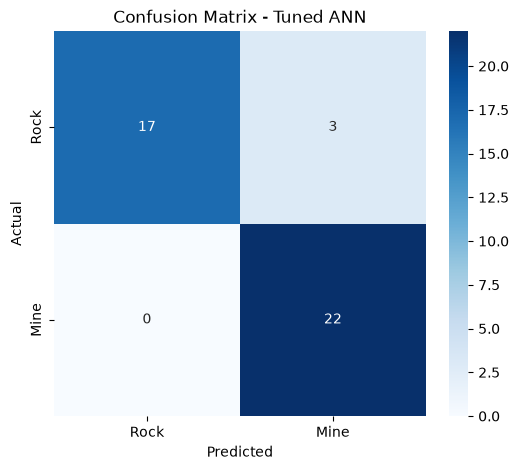

In [22]:
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rock", "Mine"],
    yticklabels=["Rock", "Mine"]
)

plt.title("Confusion Matrix - Tuned ANN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [23]:
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Basic ANN": [
        basic_metrics["Accuracy"],
        basic_metrics["Precision"],
        basic_metrics["Recall"],
        basic_metrics["F1 Score"]
    ],
    "Tuned ANN": [
        tuned_metrics["Accuracy"],
        tuned_metrics["Precision"],
        tuned_metrics["Recall"],
        tuned_metrics["F1 Score"]
    ]
})

comparison["Improvement"] = comparison["Tuned ANN"] - comparison["Basic ANN"]

comparison

,Metric,Basic ANN,Tuned ANN,Improvement
0,Accuracy,0.928571,0.928571,0.000000
1,Precision,0.913043,0.880000,-0.033043
2,Recall,0.954545,1.000000,0.045455
3,F1 Score,0.933333,0.936170,0.002837


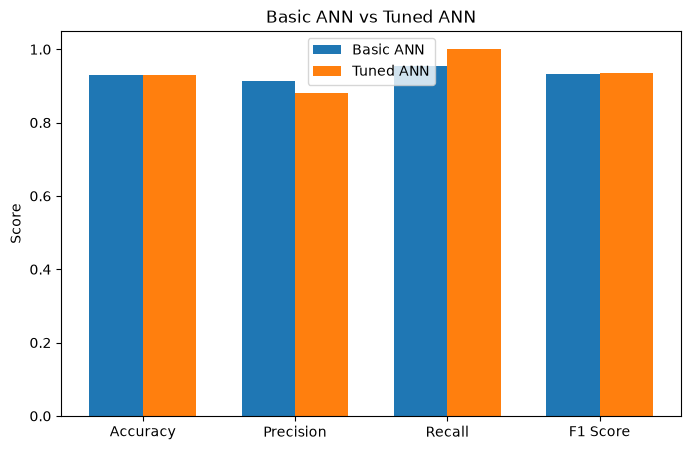

In [24]:
plt.figure(figsize=(8, 5))

x = np.arange(len(comparison["Metric"]))
width = 0.35

plt.bar(x - width/2, comparison["Basic ANN"], width, label="Basic ANN")
plt.bar(x + width/2, comparison["Tuned ANN"], width, label="Tuned ANN")

plt.xticks(x, comparison["Metric"])
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Basic ANN vs Tuned ANN")
plt.legend()
plt.show()

## 5. Discussion

The basic ANN provides a baseline for the SONAR classification problem. Hyperparameter tuning then tests whether changes to the architecture and learning process can improve validation performance.

The final tuned model should be compared with the basic model using accuracy, precision, recall and F1-score. In this application, recall for the Mine class is especially important because incorrectly classifying a real mine as a rock represents a missed detection.

The training curves should also be inspected for overfitting. If training accuracy continues to increase while validation performance stops improving or decreases, the model is learning the training data too closely. Early stopping is therefore used to restore the best validation model.

In [25]:
print("Final Results")
print("=============")
print(f"Basic ANN Accuracy : {basic_metrics['Accuracy']:.4f}")
print(f"Tuned ANN Accuracy : {tuned_metrics['Accuracy']:.4f}")
print()
print(f"Basic ANN F1 Score : {basic_metrics['F1 Score']:.4f}")
print(f"Tuned ANN F1 Score : {tuned_metrics['F1 Score']:.4f}")

Final Results
Basic ANN Accuracy : 0.9286
Tuned ANN Accuracy : 0.9286

Basic ANN F1 Score : 0.9333
Tuned ANN F1 Score : 0.9362


## 6. Conclusion

The SONAR dataset was successfully prepared and classified using an Artificial Neural Network. The dataset contained 208 observations, 60 numerical sonar features and two target classes, Mine and Rock. No missing values or duplicate records were found.

The input features were standardized before training the ANN. A basic neural network was first developed as a baseline, followed by structured hyperparameter tuning involving the number of hidden layers, neurons, activation function and learning rate.